## 1. Imports

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
from pathlib import Path
from sklearn.preprocessing import StandardScaler

sys.path.append(os.path.abspath(".."))

# EarlyFusion models
from EarlyFusion.EarlyFusionMLP import *
from EarlyFusion.EarlyFusionCNN import *
from EarlyFusion.utils import cross_validation_5fold_early_fusion, hyperparameter_tuning

## 2. Data Loading

In [2]:
AUDIO_FEATURES = "/mloscratch/users/gnahas/data/features/acoustic_features_vf.csv"
TAPPING_FEATURES = "/mloscratch/users/clerget/data/csv/tapping_combined_features_session.csv"
LABELS = "/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/paired_healthcode.csv"
TRAIN_FOLDS = "/mloscratch/users/gnahas/data/data_paired/5_fold_CV/processed_paired/paired_splits/balanced_train/healthcode_5fold_train.csv"
VAL_TEST_FOLDS = "/mloscratch/users/gnahas/data/data_paired/5_fold_CV/processed_paired/paired_splits/balanced_train/healthcode_5fold_val_test.csv"

## 3. Concatenation

In [3]:
audio_features = pd.read_csv(AUDIO_FEATURES)
tapping_features = pd.read_csv(TAPPING_FEATURES)

# Rename 'healthcode' to 'healthCode' for consistency if needed
if 'healthcode' in audio_features.columns and 'healthCode' not in audio_features.columns:
    audio_features = audio_features.rename(columns={'healthcode': 'healthCode'})

if 'healthcode' in tapping_features.columns and 'healthCode' not in TAPPING_FEATURES.columns:
    tapping_features = tapping_features.rename(columns={'healthcode': 'healthCode'})

# Count occurrences of trials per patient in each dataframe
counts_audio = audio_features["healthCode"].value_counts()
counts_tapping = tapping_features["healthCode"].value_counts()

# Consider healthCodes present in both files
shared_healthCodes = counts_audio.index.intersection(counts_tapping.index)

# Helper: minimum count of trials for each patient
min_counts = {code: min(counts_audio[code], counts_tapping[code]) for code in shared_healthCodes}

# Dropping extra audio trials per patient where needed
counts_audio_balanced = (
    audio_features[audio_features["healthCode"].isin(shared_healthCodes)]
      .groupby("healthCode")
      .apply(lambda g: g.sample(min_counts[g.name], random_state=42))
      .reset_index(drop=True)
)

# Dropping extra tapping trials per patient where needed
counts_tapping_balanced = (
    tapping_features[tapping_features["healthCode"].isin(shared_healthCodes)]
      .groupby("healthCode")
      .apply(lambda g: g.sample(min_counts[g.name], random_state=42))
      .reset_index(drop=True)
)

counts_audio_balanced["row_id"] = counts_audio_balanced.groupby("healthCode").cumcount()
counts_tapping_balanced["row_id"] = counts_tapping_balanced.groupby("healthCode").cumcount()

features_merged = pd.merge(
    counts_audio_balanced,
    counts_tapping_balanced,
    on=["healthCode", "row_id"],
    suffixes=("_file1", "_file2")
)

features_merged.to_csv("/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/fusion_features.csv", index=False)


/tmp/ipykernel_74841/2498735670.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min_counts[g.name], random_state=42))
/tmp/ipykernel_74841/2498735670.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min_counts[g.name], random_state=42))
/tmp/ipykernel_74841/2498735670.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping colum

In [3]:
FUSION_FEATURES = "/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/fusion_features.csv"

## 4. Cross-Validation

In [ ]:
output_dir_mlp = "/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/models/EarlyFusion/"

print("Running 5-fold CV with EarlyFusionMLP on Extracted Features...")
cv_results = cross_validation_5fold_early_fusion(
    features_csv=FUSION_FEATURES,
    labels_csv=LABELS,
    train_folds_csv=TRAIN_FOLDS,
    val_test_folds_csv=VAL_TEST_FOLDS,
    hidden_dims=[256, 128, 64],
    batch_size=64,
    num_epochs=150,
    learning_rate=0.001,
    weight_decay=0.01,
    dropout=0.8,
    class_weight=3,
    verbose=True
)

print(f"\nModels saved at: {cv_results['model_paths']}")

Running 5-fold CV with EarlyFusionMLP on Extracted Features...
Loaded features: (14628, 172)
  Columns: ['filename', 'healthCode', 'record_id', 'mfcc_1_mean', 'mfcc_1_std']...
Loaded labels: (532, 3)
  Columns: ['healthCode', 'label_PD', 'modality']
Train folds: (1380, 3)
  Columns: ['fold_iteration', 'healthCode', 'subset']
Val+Test folds: (1064, 3)
  Columns: ['fold_iteration', 'healthCode', 'subset']
  - Validation folds: (532, 3)
  - Test folds: (532, 3)
Features after merging with labels: (14628, 173)
Features after filtering to 5-fold healthcodes: (14628, 173)
Number of features: 167
Feature columns: ['mfcc_1_mean', 'mfcc_1_std', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_3_mean']... (showing first 5)
Using device: cuda


Fold 1/5 (Fold iteration 1)
Train patients: 276
Val patients: 107
Test patients: 107
Train samples: 7042
Val samples: 3340
Test samples: 2265
Loaded features: (14628, 172)
  Columns: ['filename', 'healthCode', 'record_id', 'mfcc_1_mean', 'mfcc_1_std']...
Loaded labels: 

/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/EarlyFusion/EarlyFusionMLP.py:160: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /opt/pytorch/pytorch/aten/src/ATen/native/Scalar.cpp:22.)
  epoch_loss += loss.item() * len(lbl)


Epoch 10/150 | Train Loss: 0.3839 | Train Acc: 0.8597 | Val Loss: 0.9024 | Val Acc: 0.5518 | Val AUC: 0.5557 | LR: 0.001000
Learning rate reduced to 0.000500
Learning rate reduced to 0.000500
Epoch 20/150 | Train Loss: 0.3184 | Train Acc: 0.8901 | Val Loss: 1.0675 | Val Acc: 0.5455 | Val AUC: 0.5166 | LR: 0.000500
Epoch 20/150 | Train Loss: 0.3184 | Train Acc: 0.8901 | Val Loss: 1.0675 | Val Acc: 0.5455 | Val AUC: 0.5166 | LR: 0.000500
Learning rate reduced to 0.000250
Learning rate reduced to 0.000250
Epoch 30/150 | Train Loss: 0.2748 | Train Acc: 0.9083 | Val Loss: 1.1099 | Val Acc: 0.5461 | Val AUC: 0.5422 | LR: 0.000250
Epoch 30/150 | Train Loss: 0.2748 | Train Acc: 0.9083 | Val Loss: 1.1099 | Val Acc: 0.5461 | Val AUC: 0.5422 | LR: 0.000250
Learning rate reduced to 0.000125
Learning rate reduced to 0.000125
Epoch 40/150 | Train Loss: 0.2446 | Train Acc: 0.9236 | Val Loss: 1.2666 | Val Acc: 0.5835 | Val AUC: 0.5356 | LR: 0.000125
Epoch 40/150 | Train Loss: 0.2446 | Train Acc: 0.923

In [4]:
output_dir_mlp = "/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/models/EarlyFusion/"

hyperparam_tuning_res = hyperparameter_tuning(
    features_csv = FUSION_FEATURES,
    labels_csv = LABELS,
    train_folds_csv = TRAIN_FOLDS,
    val_test_folds_csv = VAL_TEST_FOLDS,
    output_dir = output_dir_mlp,
    hidden_dims = [[256, 128, 64], [256, 128, 64, 32]],
    batch_size = [64],
    weight_decay = [0.01],
    dropout = [0.8, 0.75],
    class_weight = [3],
    num_epochs = [150],
    learning_rate = [0.001],
    verbose=True        
)

Testing 4 Hyperparameter Combinations

------------------------------
Hyperparameters
------------------------------
Hidden Layers: [256, 128, 64]
Batch Size: 64
Weight Decay: 0.01
Dropout: 0.8
Class Weight: 3
Num Epochs: 150
Learning Rate: 0.001
------------------------------ 



/mloscratch/users/mihaylov/NeuroMeditron/src_GAMMA/EarlyFusion/EarlyFusionMLP.py:160: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /opt/pytorch/pytorch/aten/src/ATen/native/Scalar.cpp:22.)
  epoch_loss += loss.item() * len(lbl)


Results Summary
------------------------------
Test Accuracy: 0.6769 ± 0.0553
Test F1 Score: 0.6858 ± 0.0687
Test ROC AUC:  0.7359 ± 0.0463
------------------------------ 

Found New Best Model!
------------------------------ 

------------------------------
Hyperparameters
------------------------------
Hidden Layers: [256, 128, 64]
Batch Size: 64
Weight Decay: 0.01
Dropout: 0.75
Class Weight: 3
Num Epochs: 150
Learning Rate: 0.001
------------------------------ 

Results Summary
------------------------------
Test Accuracy: 0.6862 ± 0.0553
Test F1 Score: 0.7024 ± 0.0580
Test ROC AUC:  0.7248 ± 0.0528
------------------------------ 

------------------------------
Hyperparameters
------------------------------
Hidden Layers: [256, 128, 64, 32]
Batch Size: 64
Weight Decay: 0.01
Dropout: 0.8
Class Weight: 3
Num Epochs: 150
Learning Rate: 0.001
------------------------------ 

Results Summary
------------------------------
Test Accuracy: 0.6562 ± 0.0568
Test F1 Score: 0.6481 ± 0.0758
Tes

## 5. Results Visualization

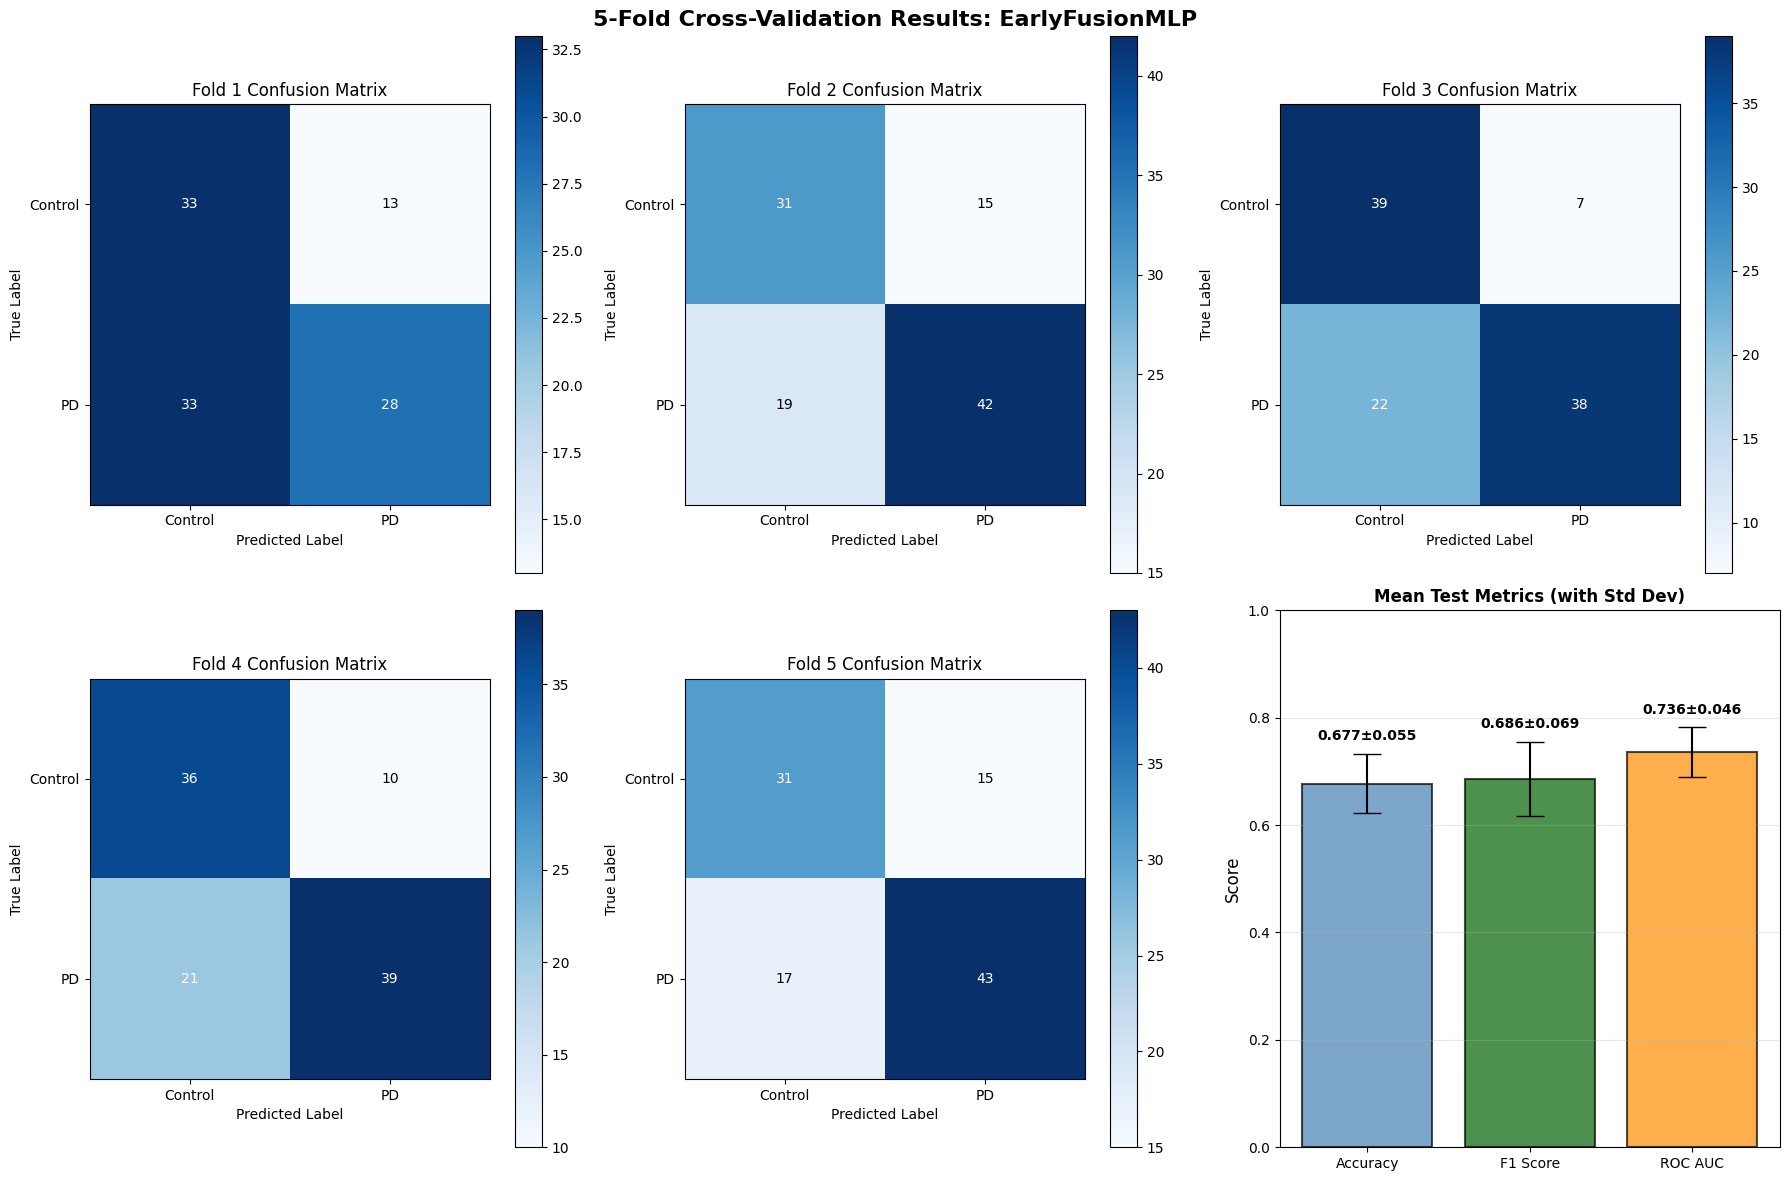


Summary Statistics:
Test Accuracy: 0.6769 ± 0.0553
Test F1 Score: 0.6858 ± 0.0687
Test ROC AUC:  0.7359 ± 0.0463


In [5]:
# Create visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('5-Fold Cross-Validation Results: EarlyFusionMLP', fontsize=16, fontweight='bold')

# Plot confusion matrices for each fold
for i, cm in enumerate(hyperparam_tuning_res['confusion_matrices']):
    if i < 5:  # We have 5 folds
        row = i // 3
        col = i % 3
        ax = axes[row, col]
        
        # Plot confusion matrix as heatmap
        im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        ax.set_title(f'Fold {i + 1} Confusion Matrix')
        ax.set_xlabel('Predicted Label')
        ax.set_ylabel('True Label')
        
        # Add colorbar
        plt.colorbar(im, ax=ax)
        
        # Add text annotations
        thresh = cm.max() / 2.
        for row_idx in range(cm.shape[0]):
            for col_idx in range(cm.shape[1]):
                ax.text(col_idx, row_idx, format(cm[row_idx, col_idx], 'd'),
                       ha="center", va="center",
                       color="white" if cm[row_idx, col_idx] > thresh else "black")
        
        # Set ticks
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(['Control', 'PD'])
        ax.set_yticklabels(['Control', 'PD'])

# Plot mean metrics with error bars in the last subplot
ax = axes[1, 2]
metrics = ['Accuracy', 'F1 Score', 'ROC AUC']
means = [hyperparam_tuning_res['mean_test_acc'], hyperparam_tuning_res['mean_test_f1'], hyperparam_tuning_res['mean_test_roc_auc']]
stds = [hyperparam_tuning_res['std_test_acc'], hyperparam_tuning_res['std_test_f1'], hyperparam_tuning_res['std_test_roc_auc']]

x_pos = np.arange(len(metrics))
bars = ax.bar(x_pos, means, yerr=stds, align='center', alpha=0.7, 
              color=['steelblue', 'darkgreen', 'darkorange'], 
              ecolor='black', capsize=10, edgecolor='black', linewidth=1.5)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Mean Test Metrics (with Std Dev)', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(metrics)
ax.set_ylim([0, 1.0])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (mean, std) in enumerate(zip(means, stds)):
    ax.text(i, mean + std + 0.02, f'{mean:.3f}±{std:.3f}', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSummary Statistics:")
print(f"Test Accuracy: {hyperparam_tuning_res['mean_test_acc']:.4f} ± {hyperparam_tuning_res['std_test_acc']:.4f}")
print(f"Test F1 Score: {hyperparam_tuning_res['mean_test_f1']:.4f} ± {hyperparam_tuning_res['std_test_f1']:.4f}")
print(f"Test ROC AUC:  {hyperparam_tuning_res['mean_test_roc_auc']:.4f} ± {hyperparam_tuning_res['std_test_roc_auc']:.4f}")